# Notebook 9 – Outlier Detection

# Topic 1 – What are Outliers?

## Step 1 – Understand the Concept

An outlier is a data point that is unusually far away from the other observations in a dataset.

It may be much smaller or much larger than most of the other values.

For example:

Data = [10, 12, 11, 13, 12, 14, 100]

Most values are between 10 and 14, but 100 is very different from the other values.

Therefore, 100 can be considered an outlier.

An outlier can occur because of:

- Measurement errors
- Data entry mistakes
- Unusual events
- Natural variation
- Genuine rare observations

Outliers should not always be removed. First, we should understand why the value is unusual.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose the ages of people in a classroom are:

18, 19, 20, 21, 19, 20, 65

The value 65 is much higher than the other observations.

It may be an outlier, but we should first check whether it is a data entry error or a genuine observation.

### Numerical Example

Data:

10, 12, 11, 13, 12, 14, 100

The value 100 is far away from the majority of the observations.

### Business Example

A company records customer purchase amounts:

₹500, ₹700, ₹650, ₹800, ₹600, ₹50,000

₹50,000 is unusually high compared with the other purchases.

The company should investigate whether it is a genuine large purchase or a data error.

### AI/ML Example

In a Machine Learning dataset, an extreme value in a feature such as salary, age, or transaction amount can affect statistical analysis and some models.

Therefore, outlier detection is an important part of Exploratory Data Analysis.


## Step 3 – Implement the Concept

In [1]:
import numpy as np

data = np.array([10, 12, 11, 13, 12, 14, 100])

mean = np.mean(data)

print("Data:", data)
print("Mean:", mean)

Data: [ 10  12  11  13  12  14 100]
Mean: 24.571428571428573


## Interpretation

The value 100 is much larger than the other observations.

Because of this extreme value, the mean is pulled upward.

This demonstrates why outliers can affect statistical measures such as the mean.

## Advantages

- Helps identify unusual observations.
- Useful for data cleaning.
- Can improve the quality of statistical analysis.
- Important during EDA.

## Limitations

- An outlier may be a genuine observation.
- Detection does not automatically mean the value should be removed.
- Different methods may identify different observations as outliers.

# Topic 2 – Types of Outliers

## Step 1 – Understand the Concept

Outliers can occur in different ways.

### 1. Point Outlier

A single observation is significantly different from the rest of the data.

Example:

10, 11, 12, 13, 100

Here, 100 may be a point outlier.

### 2. Contextual Outlier

A value may be unusual only in a specific context.

For example, 35°C may be normal during summer but unusual for a particular winter day.

### 3. Collective Outlier

A group of observations behaves unusually even though individual values may not look extreme by themselves.

For example, a sequence of unusual network requests may indicate abnormal activity.

Understanding the type of outlier helps us decide how to investigate it.

## Step 2 – Demonstrate the Concept

### Real-World Example

A temperature of 40°C may be normal in one location during summer but unusual in another location during winter.

This is a contextual outlier.

### Numerical Example

Data:

10, 11, 12, 13, 100

100 is a point outlier.

### Business Example

A sudden group of unusually high transactions occurring within a short period may represent a collective outlier pattern.

### AI/ML Example

In fraud detection, one transaction may be unusual by itself, or a sequence of transactions may collectively indicate suspicious behavior.

Therefore, AI/ML systems may need to consider both individual and contextual patterns.

## Interpretation

Different types of outliers require different investigation methods.

A single extreme value can often be detected using statistical methods such as IQR or Z-Score.

Contextual and collective outliers may require additional domain knowledge or more advanced anomaly detection techniques.

## Advantages

- Helps us understand why an observation is unusual.
- Supports better data investigation.
- Useful in fraud detection, monitoring, and anomaly detection.

## Limitations

- Classification depends on the context.
- Statistical methods may not detect every type of outlier.
- Domain knowledge may be required.

# Topic 3 – Detecting Outliers

## Step 1 – Understand the Concept

Outliers can be detected using statistical methods and visualization.

Common methods include:

1. IQR Method
2. Z-Score Method
3. Box Plot
4. Scatter Plot

The choice of method depends on the dataset and the type of relationship being analyzed.

In this notebook, I will mainly use IQR and Z-Score methods.

## Step 2 – Demonstrate the Concept

### Real-World Example

A company may analyze employee salaries and detect unusually high or low salary values.

### Numerical Example

Data:

10, 12, 11, 13, 12, 14, 100

The value 100 can be detected as an unusual observation.

### Business Example

A bank can detect unusually large transactions to investigate possible fraud.

### AI/ML Example

Outlier detection can be used during preprocessing to identify unusual feature values before training a Machine Learning model.

However, removing outliers should be done carefully because some unusual observations may contain important information.



## Common Detection Methods

### IQR Method

The IQR method uses:

- Q1 → First quartile
- Q3 → Third quartile
- IQR = Q3 - Q1

Lower Bound:

Q1 - 1.5 × IQR

Upper Bound:

Q3 + 1.5 × IQR

Values outside these bounds are commonly flagged as potential outliers.

### Z-Score Method

Z-score measures how many standard deviations an observation is away from the mean.

Formula:

z = (x - μ) / σ

A common rule is to investigate observations with:

|z| > 3

This is a rule of thumb and works best under assumptions where the mean and standard deviation are appropriate.

# Topic 4 – IQR Method

## Step 1 – Understand the Concept

IQR stands for Interquartile Range.

It measures the spread of the middle 50% of the data.

IQR is calculated as:

IQR = Q3 - Q1

Where:

- Q1 = 25th percentile
- Q3 = 75th percentile

Outlier boundaries are calculated as:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any value below the lower bound or above the upper bound is flagged as a potential outlier.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose a company has customer purchase amounts.

Most customers spend between ₹500 and ₹2,000, but one customer spends ₹50,000.

The IQR method can help identify this unusually large transaction.

### Numerical Example

Data:

10, 12, 13, 14, 15, 16, 18, 100

If 100 is outside the calculated upper bound, it is identified as a potential outlier.

### Business Example

An e-commerce company can use IQR to detect unusually high order values.

### AI/ML Example

Before training a model, IQR can be used to identify extreme values in numerical features such as income, age, transaction amount, or house prices.


## Step 3 – Implement the Concept

In [2]:
import numpy as np

data = np.array([10, 12, 13, 14, 15, 16, 18, 100])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Q1: 12.75
Q3: 16.5
IQR: 3.75
Lower Bound: 7.125
Upper Bound: 22.125
Outliers: [100]


## Interpretation

The program calculates Q1, Q3, and IQR.

It then calculates the lower and upper bounds.

Any value outside these bounds is identified as a potential outlier.

In this dataset, 100 is expected to be detected as an outlier.

## Advantages

- Simple and easy to understand.
- Does not require the data to follow a normal distribution.
- Less affected by extreme values than mean-based methods.
- Useful for skewed data.

## Limitations

- The 1.5 × IQR rule is a convention, not a universal law.
- It may flag valid extreme observations.
- It is mainly designed for numerical variables.

# Topic 5 – Z-Score Method

## Step 1 – Understand the Concept

A Z-score tells us how far an observation is from the mean in terms of standard deviations.

Formula:

z = (x - μ) / σ

Where:

- x = Observation
- μ = Mean
- σ = Standard deviation

A positive Z-score means the value is above the mean.

A negative Z-score means the value is below the mean.

A common rule of thumb is to investigate values where:

|z| > 3

Such observations are often considered potential outliers when the assumptions of the method are reasonable.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose the average delivery time is 30 minutes.

If one delivery takes an unusually long time compared with the average, its Z-score may be large.

### Numerical Example

If:

Mean = 50

Standard Deviation = 10

Observation = 90

Then:

z = (90 - 50) / 10

z = 4

The observation is 4 standard deviations above the mean and may be considered a potential outlier.

### Business Example

A company can use Z-scores to identify unusually high or low sales values.

### AI/ML Example

Z-score based detection can be used during data preprocessing to identify extreme numerical feature values.


## Step 3 – Implement the Concept

In [3]:
import numpy as np
from scipy.stats import zscore

data = np.array([10, 12, 13, 14, 15, 16, 18, 100])

z_scores = zscore(data)

print("Data:", data)
print("Z-Scores:", z_scores)

outliers = data[np.abs(z_scores) > 2]

print("Potential Outliers:", outliers)

Data: [ 10  12  13  14  15  16  18 100]
Z-Scores: [-0.5169277  -0.44683581 -0.41178986 -0.37674392 -0.34169797 -0.30665203
 -0.23656013  2.63720742]
Potential Outliers: [100]


## Interpretation

The program calculates the Z-score for each observation.

Values with an absolute Z-score greater than the selected threshold are flagged as potential outliers.

Here, the threshold is set to 2 for demonstration.

In practice, the threshold should be chosen based on the dataset, assumptions, and problem context.

## Advantages

- Simple mathematical approach.
- Shows how far a value is from the mean.
- Useful when mean and standard deviation are appropriate.
- Easy to implement with SciPy.

## Limitations

- Sensitive to extreme values because mean and standard deviation can themselves be affected by outliers.
- Works best when the distribution and assumptions are appropriate.
- The threshold is not universal.

# Topic 6 – Box Plot

## Step 1 – Understand the Concept

A box plot is a statistical visualization that summarizes the distribution of numerical data.

It shows:

- Minimum / lower whisker
- Q1
- Median
- Q3
- Maximum / upper whisker

Potential outliers are commonly displayed as individual points beyond the whiskers.

Box plots are useful because they show the spread, center, and potential outliers in one visualization.

## Step 2 – Demonstrate the Concept

### Real-World Example

A school can use a box plot to visualize the distribution of exam marks and identify unusually low or high scores.

### Numerical Example

Data:

10, 12, 13, 14, 15, 16, 18, 100

The value 100 is far away from the majority of observations and can appear separately in the box plot.

### Business Example

A company can use box plots to compare customer spending across different regions.

### AI/ML Example

During EDA, box plots can help identify possible outliers in numerical features before building a Machine Learning model.


## Step 3 – Implement the Concept

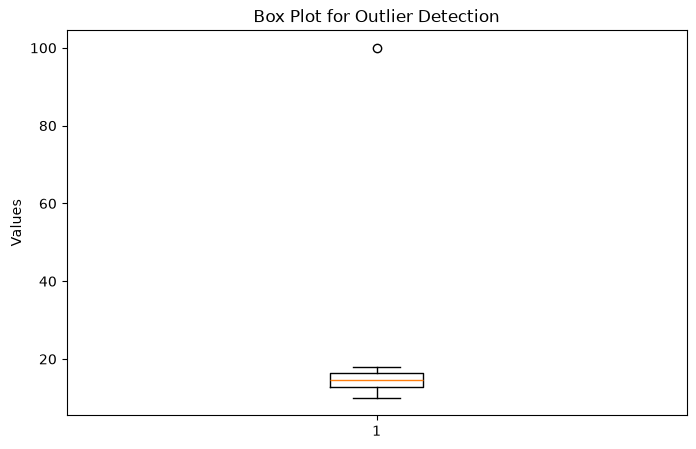

In [4]:
import matplotlib.pyplot as plt

data = [10, 12, 13, 14, 15, 16, 18, 100]

plt.figure(figsize=(8, 5))

plt.boxplot(data)

plt.title("Box Plot for Outlier Detection")
plt.ylabel("Values")

plt.show()

## Interpretation

The box plot summarizes the distribution of the data.

The value 100 is expected to appear separately from the main group because it is much larger than the other observations.

This makes a box plot useful for quickly identifying potential outliers.

## Advantages

- Easy visual detection of potential outliers.
- Shows median and quartiles.
- Useful for comparing multiple groups.
- Compact representation of data distribution.

## Limitations

- Does not explain why a value is an outlier.
- A potential outlier may be a genuine observation.
- For very large datasets, additional analysis may be required.

# Topic 7 – Scatter Plot

## Step 1 – Understand the Concept

A scatter plot displays individual observations as points on a graph.

It is useful for studying the relationship between two numerical variables.

Outliers may appear as points that are far away from the main group of observations.

Scatter plots can help identify:

- Relationships
- Clusters
- Trends
- Potential outliers

## Step 2 – Demonstrate the Concept

### Real-World Example

A scatter plot can show the relationship between house size and house price.

Most houses may follow a general pattern, while one unusually expensive house may appear far away from the main group.

### Numerical Example

X = [1, 2, 3, 4, 5, 10]

Y = [2, 4, 6, 8, 10, 50]

The point (10, 50) is far away from the main group.

### Business Example

A company can plot advertising expenditure against sales.

An unusual observation may represent a campaign with exceptionally high sales.

### AI/ML Example

Scatter plots are useful during EDA to identify unusual observations and understand relationships between numerical features.


## Step 3 – Implement the Concept

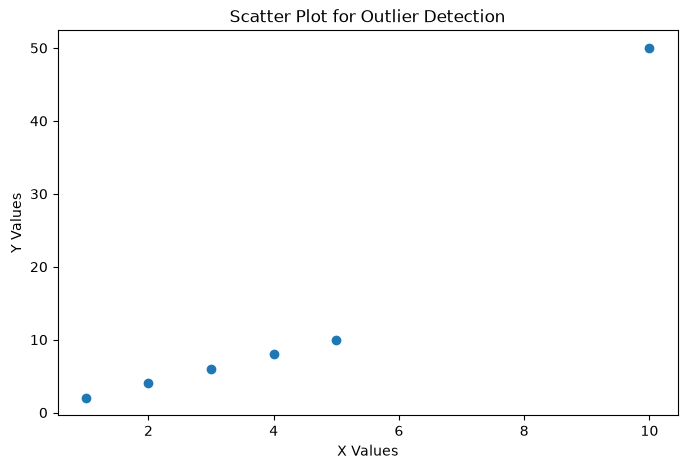

In [5]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5, 10]
y = [2, 4, 6, 8, 10, 50]

plt.figure(figsize=(8, 5))

plt.scatter(x, y)

plt.title("Scatter Plot for Outlier Detection")
plt.xlabel("X Values")
plt.ylabel("Y Values")

plt.show()

## Interpretation

The scatter plot shows the relationship between X and Y.

Most observations follow a general pattern, while the point (10, 50) is far away from the main group.

This makes it a potential outlier.

## Advantages

- Easy to visualize relationships.
- Can identify unusual observations.
- Useful for EDA.
- Helps detect outliers in two-dimensional data.

## Limitations

- Not suitable for detecting all types of outliers.
- A point may appear unusual visually but may be valid.
- With many observations, points may overlap.